# Havayolu Veri Seti Analizi ve Makine Öğrenmesi Projesi

Bu projede, 'Airline Dataset.csv' veri seti kullanılarak uçuş durumu (Flight Status) tahmini yapılıyor.


In [1]:
# Gerekli kütüphanelerin import edilmesi
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Grafiklerin daha iyi görünmesi için
plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = (12, 8)

In [2]:
# Veri setini yerel dizinden yükleme
data = pd.read_csv('Airline Dataset.csv')

# Veri setinin ilk satırlarına bakalım
data.head()

,Passenger ID,First Name,Last Name,Gender,Age,Nationality,Airport Name,Airport Country Code,Country Name,Airport Continent,Continents,Departure Date,Arrival Airport,Pilot Name,Flight Status
0,10856,Edithe,Leggis,Female,62,Japan,Coldfoot Airport,US,United States,NAM,North America,6/28/2022,CXF,Edithe Leggis,On Time
1,43872,Elwood,Catt,Male,62,Nicaragua,Kugluktuk Airport,CA,Canada,NAM,North America,12/26/2022,YCO,Elwood Catt,On Time
2,42633,Darby,Felgate,Male,67,Russia,Grenoble-Isère Airport,FR,France,EU,Europe,1/18/2022,GNB,Darby Felgate,On Time
3,78493,Dominica,Pyle,Female,71,China,Ottawa / Gatineau Airport,CA,Canada,NAM,North America,9/16/2022,YND,Dominica Pyle,Delayed
4,82072,Bay,Pencost,Male,21,China,Gillespie Field,US,United States,NAM,North America,2/25/2022,SEE,Bay Pencost,On Time


## 1. Veri Keşfi ve Ön İşleme

Havayolu veri setini seçme sebebimiz, günümüzde havayolu şirketlerinin karşılaştığı en büyük sorunlardan biri olan uçuş gecikmelerini ve iptalleri tahmin edebilecek bir model geliştirmektir.


Eksik Değer Sayısı:
Passenger ID            0
First Name              0
Last Name               0
Gender                  0
Age                     0
Nationality             0
Airport Name            0
Airport Country Code    0
Country Name            0
Airport Continent       0
Continents              0
Departure Date          0
Arrival Airport         0
Pilot Name              0
Flight Status           0
dtype: int64


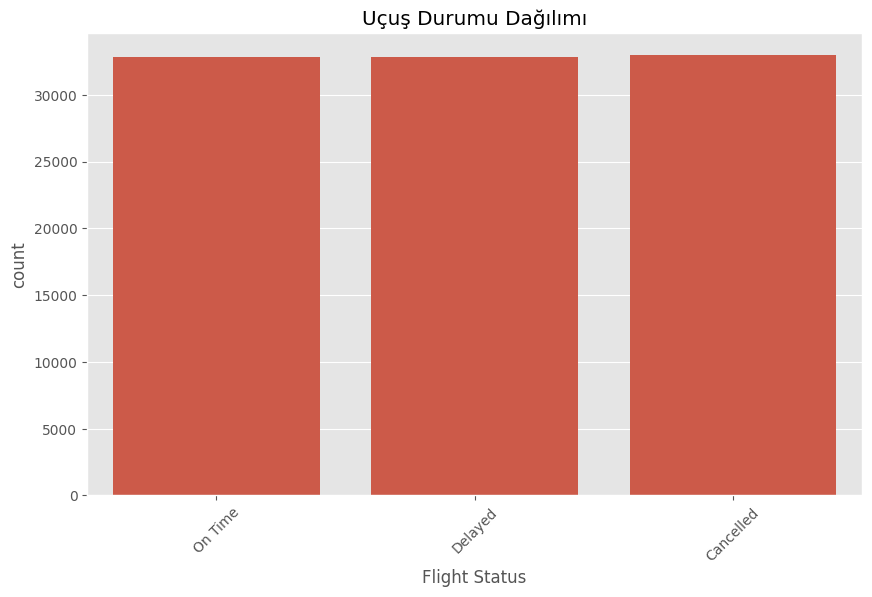

In [3]:
# Veri setindeki eksik değerleri kontrol edelim
print("Eksik Değer Sayısı:")
print(data.isnull().sum())

# Flight Status dağılımını görelim (hedef değişkenimiz)
plt.figure(figsize=(10, 6))
sns.countplot(data=data, x='Flight Status')
plt.title('Uçuş Durumu Dağılımı')
plt.xticks(rotation=45)
plt.show()

In [4]:
# Age değişkeni için aykırı değer analizi
Q1 = data['Age'].quantile(0.25)
Q3 = data['Age'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Aykırı değerleri çıkarmak yerine sınırlayoruz (Capping)
data_capped = data.copy()
data_capped.loc[data_capped['Age'] < lower_bound, 'Age'] = lower_bound
data_capped.loc[data_capped['Age'] > upper_bound, 'Age'] = upper_bound

# İleriki analizler için aykırı değerleri sınırlandırılmış veri setini kullanıyoruz
data = data_capped

C:\Users\tahaemre\AppData\Local\Temp\ipykernel_7952\2647394983.py:10: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '-44.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  data_capped.loc[data_capped['Age'] < lower_bound, 'Age'] = lower_bound


In [5]:
# Kullanmayacağımız sütunları belirleyelim
drop_columns = ['Passenger ID', 'First Name', 'Last Name', 'Pilot Name', 'Departure Date', 'Airport Name']

# Modelleme için veri setini hazırlayalım
model_data = data.drop(drop_columns, axis=1)

# Kategorik değişkenleri sayısallaştıralım (One-Hot Encoding)
categorical_columns = ['Gender', 'Nationality', 'Airport Country Code', 'Country Name',
                      'Airport Continent', 'Continents', 'Arrival Airport']

# Çok fazla kategori olduğu için en sık görülen kategorileri alalım
for column in categorical_columns:
    top_categories = model_data[column].value_counts().nlargest(10).index
    model_data[column] = model_data[column].apply(lambda x: x if x in top_categories else 'Other')

# One-Hot Encoding uygulayalım
model_data = pd.get_dummies(model_data, columns=categorical_columns, drop_first=True)

# Target değişkenini numerik hale getirelim
status_mapping = {'On Time': 0, 'Delayed': 1, 'Cancelled': 2}
model_data['Flight_Status_Numeric'] = model_data['Flight Status'].map(status_mapping)
model_data = model_data.drop('Flight Status', axis=1)

In [6]:
from sklearn.preprocessing import MinMaxScaler

# Target değişkenini ayıralım
X = model_data.drop('Flight_Status_Numeric', axis=1)
y = model_data['Flight_Status_Numeric']

# MinMaxScaler ile normalizasyon (0-1 aralığına getirme)
min_max_scaler = MinMaxScaler()
X_normalized = pd.DataFrame(min_max_scaler.fit_transform(X), columns=X.columns)

In [7]:
from sklearn.feature_selection import SelectKBest, chi2, f_classif
from sklearn.ensemble import RandomForestClassifier

# 1. Yöntem: Chi-Square Testi
k_best_chi2 = SelectKBest(chi2, k=15)
X_chi2 = k_best_chi2.fit_transform(X_normalized, y)
selected_features_chi2 = X_normalized.columns[k_best_chi2.get_support()]

# 2. Yöntem: ANOVA F-Değeri
k_best_f = SelectKBest(f_classif, k=15)
X_f = k_best_f.fit_transform(X_normalized, y)
selected_features_f = X_normalized.columns[k_best_f.get_support()]

# 3. Yöntem: Random Forest Özellik Önem Dereceleri
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_normalized, y)
feature_importance = pd.DataFrame({'Feature': X_normalized.columns, 'Importance': rf.feature_importances_})
feature_importance = feature_importance.sort_values('Importance', ascending=False)
selected_features_rf = feature_importance.head(15)['Feature'].values

In [8]:
from sklearn.model_selection import train_test_split

# Özellik setleri ile eğitim ve test verileri oluşturalım
# Chi-Square ile seçilen özellikler
X_chi2_selected = X_normalized[selected_features_chi2]
X_train_chi2, X_test_chi2, y_train_chi2, y_test_chi2 = train_test_split(X_chi2_selected, y, test_size=0.2, random_state=42)

# ANOVA F-Değeri ile seçilen özellikler
X_f_selected = X_normalized[selected_features_f]
X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(X_f_selected, y, test_size=0.2, random_state=42)

# Random Forest Özellik Önem Dereceleri ile seçilen özellikler
X_rf_selected = X_normalized[selected_features_rf]
X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(X_rf_selected, y, test_size=0.2, random_state=42)

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import time

# Sonuçları saklamak için dizi
results = {}

def train_and_evaluate_model(model_name, model, X_train, X_test, y_train, y_test, feature_set_name):
    start_time = time.time()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    training_time = time.time() - start_time

    # Performans metriklerini hesapla
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    conf_matrix = confusion_matrix(y_test, y_pred)

    # Sonuçları kaydet
    key = f"{model_name}_{feature_set_name}"
    results[key] = {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'conf_matrix': conf_matrix,
        'training_time': training_time
    }

    return model

In [10]:
# Lojistik Regresyon modelini eğitelim
lr_chi2 = train_and_evaluate_model("Lojistik Regresyon", LogisticRegression(max_iter=1000, random_state=42),
                                  X_train_chi2, X_test_chi2, y_train_chi2, y_test_chi2, "Chi-Square")
lr_f = train_and_evaluate_model("Lojistik Regresyon", LogisticRegression(max_iter=1000, random_state=42),
                               X_train_f, X_test_f, y_train_f, y_test_f, "ANOVA F-Değeri")
lr_rf = train_and_evaluate_model("Lojistik Regresyon", LogisticRegression(max_iter=1000, random_state=42),
                                X_train_rf, X_test_rf, y_train_rf, y_test_rf, "Random Forest")

In [11]:
# K-NN modelini eğitelim
knn_chi2 = train_and_evaluate_model("K-NN", KNeighborsClassifier(n_neighbors=5),
                                   X_train_chi2, X_test_chi2, y_train_chi2, y_test_chi2, "Chi-Square")
knn_f = train_and_evaluate_model("K-NN", KNeighborsClassifier(n_neighbors=5),
                                X_train_f, X_test_f, y_train_f, y_test_f, "ANOVA F-Değeri")
knn_rf = train_and_evaluate_model("K-NN", KNeighborsClassifier(n_neighbors=5),
                                 X_train_rf, X_test_rf, y_train_rf, y_test_rf, "Random Forest")

In [12]:
# Naive Bayes modelini eğitelim
nb_chi2 = train_and_evaluate_model("Naive Bayes", GaussianNB(),
                                  X_train_chi2, X_test_chi2, y_train_chi2, y_test_chi2, "Chi-Square")
nb_f = train_and_evaluate_model("Naive Bayes", GaussianNB(),
                               X_train_f, X_test_f, y_train_f, y_test_f, "ANOVA F-Değeri")
nb_rf = train_and_evaluate_model("Naive Bayes", GaussianNB(),
                                X_train_rf, X_test_rf, y_train_rf, y_test_rf, "Random Forest")

In [13]:
# Random Forest modelini eğitelim
rf_chi2 = train_and_evaluate_model("Random Forest", RandomForestClassifier(n_estimators=100, random_state=42),
                                  X_train_chi2, X_test_chi2, y_train_chi2, y_test_chi2, "Chi-Square")
rf_f = train_and_evaluate_model("Random Forest", RandomForestClassifier(n_estimators=100, random_state=42),
                               X_train_f, X_test_f, y_train_f, y_test_f, "ANOVA F-Değeri")
rf_rf = train_and_evaluate_model("Random Forest", RandomForestClassifier(n_estimators=100, random_state=42),
                                X_train_rf, X_test_rf, y_train_rf, y_test_rf, "Random Forest")

In [14]:
# Modellerin performans sonuçlarını karşılaştıralım
results_df = pd.DataFrame([
    {
        'Model': model_name.split('_')[0],
        'Özellik Seti': model_name.split('_')[1],
        'Doğruluk': results[model_name]['accuracy'],
        'Kesinlik (Precision)': results[model_name]['precision'],
        'Duyarlılık (Recall)': results[model_name]['recall'],
        'F1 Skoru': results[model_name]['f1']
    } for model_name in results.keys()
])

# Doğruluk skoruna göre sıralayalım
results_df = results_df.sort_values('Doğruluk', ascending=False)

# Sonuçları gösterelim
print("En Yüksek Doğruluk Skoruna Sahip Modeller:")
results_df[['Model', 'Özellik Seti', 'Doğruluk', 'F1 Skoru']]

En Yüksek Doğruluk Skoruna Sahip Modeller:


,Model,Özellik Seti,Doğruluk,F1 Skoru
5,K-NN,Random Forest,0.338826,0.331621
6,Naive Bayes,Chi-Square,0.336392,0.255149
7,Naive Bayes,ANOVA F-Değeri,0.336392,0.255149
3,K-NN,Chi-Square,0.334567,0.295104
4,K-NN,ANOVA F-Değeri,0.334567,0.295104
9,Random Forest,Chi-Square,0.333046,0.257613
10,Random Forest,ANOVA F-Değeri,0.333046,0.257613
0,Lojistik Regresyon,Chi-Square,0.332894,0.256835
1,Lojistik Regresyon,ANOVA F-Değeri,0.332894,0.256835
11,Random Forest,Random Forest,0.331626,0.331491
